In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [35]:
df = pd.read_csv("iris.csv")

In [36]:
df = df.drop("Id", axis=1)

In [37]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [38]:
# Format target column

In [39]:
df["Species"].str.split("-").str[1].str.capitalize()

0         Setosa
1         Setosa
2         Setosa
3         Setosa
4         Setosa
         ...    
145    Virginica
146    Virginica
147    Virginica
148    Virginica
149    Virginica
Name: Species, Length: 150, dtype: object

In [40]:
df["Species"] = df["Species"].str.split("-").str[1].str.capitalize()

In [41]:
features = df.drop("Species", axis=1).columns.to_list()

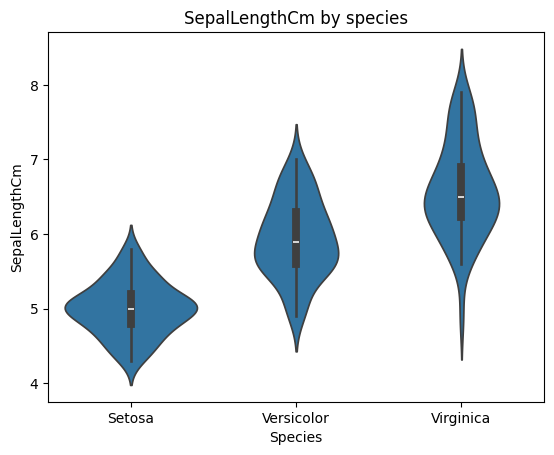

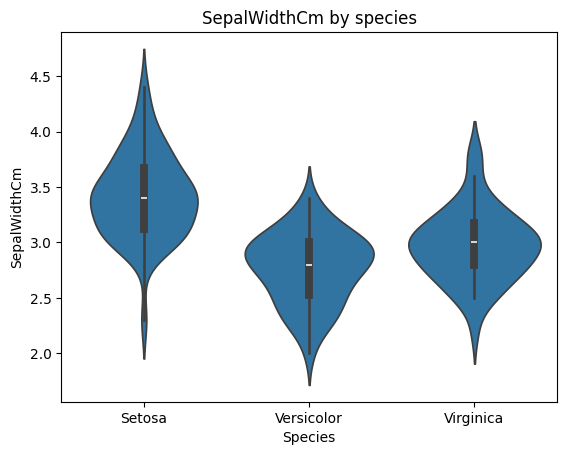

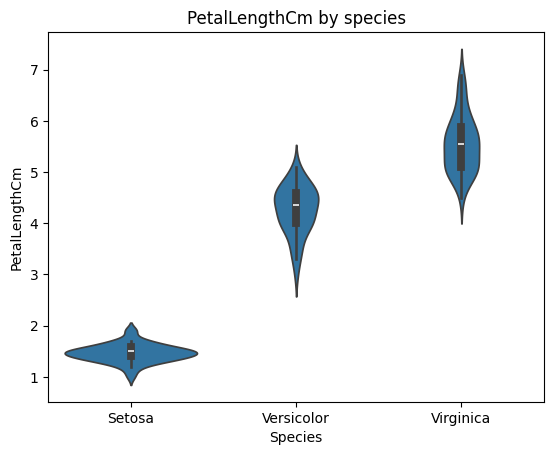

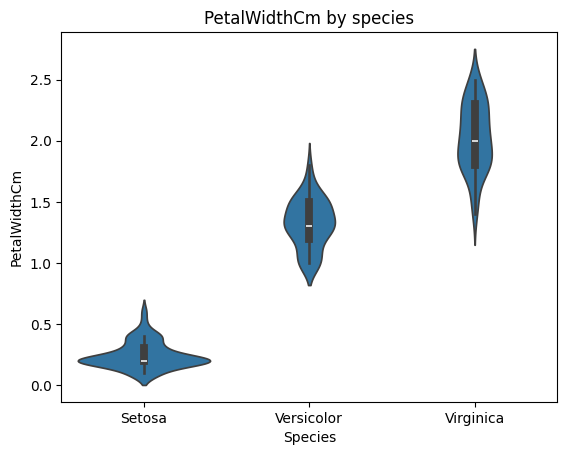

In [42]:
# Visualize against target by hue
for feature in features:
    sns.violinplot(df, x="Species", y=feature)
    plt.title(f"{feature} by species")
    plt.show()

In [70]:
X = df.drop("Species", axis=1)
y = df["Species"]

X = sm.add_constant(X)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardize = X_train.drop("const", axis=1).columns.to_list()
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])

In [80]:
model = sm.MNLogit(y_train, X_train).fit(maxiter=50)
print(model.summary())

         Current function value: 0.046578
         Iterations: 50
                          MNLogit Regression Results                          
Dep. Variable:                Species   No. Observations:                  120
Model:                        MNLogit   Df Residuals:                      110
Method:                           MLE   Df Model:                            8
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                  0.9576
Time:                        16:16:51   Log-Likelihood:                -5.5894
converged:                      False   LL-Null:                       -131.81
Covariance Type:            nonrobust   LLR p-value:                 5.240e-50
Species=Versicolor       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 28.1811    3.1e+07    9.1e-07      1.000   -6.07e+07    6.07e+07
SepalLengthCm          1.1243   1.92e+07 

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


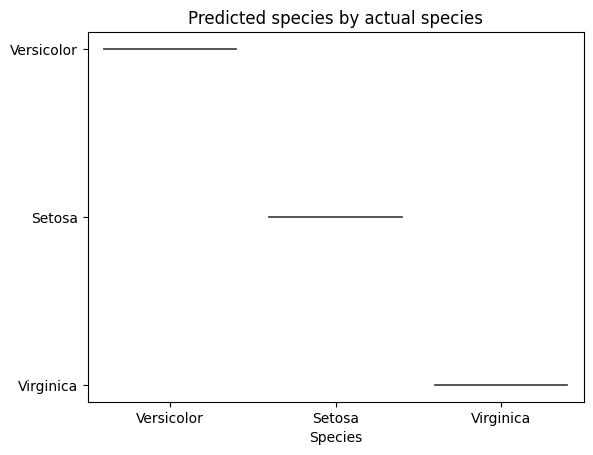

In [81]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=50)
logistic_model.fit(X_train.drop("const", axis=1), y_train)
# Evaluate model
from sklearn.metrics import accuracy_score, classification_report
y_pred = logistic_model.predict(X_test.drop("const", axis=1))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
# Visualize predictions
sns.violinplot(x=y_test, y=y_pred)
plt.title("Predicted species by actual species")
plt.show()

In [49]:
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="Species")  # Species = 0, 1, 2

# Scale features to prevent overflow in exp()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Add intercept column
X_scaled = sm.add_constant(X_scaled)

# Fit multinomial logistic regression
model = sm.MNLogit(y, X_scaled).fit(method='newton', maxiter=100, disp=True)

# Print model summary
print(model.summary())

         Current function value: 0.039662
         Iterations: 100
                          MNLogit Regression Results                          
Dep. Variable:                Species   No. Observations:                  150
Model:                        MNLogit   Df Residuals:                      140
Method:                           MLE   Df Model:                            8
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                  0.9639
Time:                        16:09:48   Log-Likelihood:                -5.9493
converged:                      False   LL-Null:                       -164.79
Covariance Type:            nonrobust   LLR p-value:                 7.055e-64
        Species=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                33.7581   1.16e+06   2.91e-05      1.000   -2.27e+06    2.27e+06
sepal length (cm)    -3.3572   6.51e+05  -5

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
